Prompt:
I need to create a Text to Image diffusion Model like GLIDE using the labels on YELP dataset.

- I already have a script to load the images with tensorflow, augment I need one to run the diffusor model with the labels, preferably Stable Diffusion
- Generate a A TensorFlow-compatible UNet (for diffusion), A noise scheduler like DDPM and a  simple tokenizer + text embedding block
- Also help me with the train loop, I want to generate sample images and log visualizations as I will leave it running

We will do step by step ask me when you need to go to the next step.

OpenAI. (2025). Training a DCGAN [ChatGPT response]. OpenAI. Retrieved March 29, 2025, from https://chat.openai.com

In [1]:
import json
import os
import tensorflow as tf
import pandas as pd
from pathlib import Path
from scipy.linalg import sqrtm
from scipy.stats import entropy
import numpy as np
import shutil

PHOTOS_DIR = 'data/photos'
JSON_PATH = 'data/photos.json'

df_photos = pd.read_json('data/clean_photos.json', lines=True)

SOURCE_DIR = Path("data/photos")
DEST_DIR = Path("data/drinks")

# Enable dynamic GPU memory growth
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)


2025-03-30 11:04:06.625683: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-30 11:04:06.634771: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743347046.644348    9416 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743347046.647216    9416 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743347046.655360    9416 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

### Filtering only not null captions

In [2]:
import pandas as pd
import os
import re

def clean_caption(text):
    text = str(text).strip()
    text = re.sub(r"<.*?>", "", text)               # Remove
    text = re.sub(r"\s+", " ", text)                # Normal
    text = re.sub(r"[^a-zA-Z0-9\s.,!?\"'()\-:]", "", text)  
    return text

def filter_and_clean_captions(json_path, image_dir):
    df = pd.read_json(json_path, lines=True)

    # Drop rows with missing or empty captions
    df = df[df['caption'].notnull()]
    df = df[df['caption'].str.strip() != ""]

    # Clean captions
    df['caption'] = df['caption'].apply(clean_caption)

    # Drop entries where image is missing
    df['image_path'] = df['photo_id'].apply(lambda pid: os.path.join(image_dir, f"{pid}.jpg"))
    df = df[df['image_path'].apply(os.path.exists)]

    return df[['image_path', 'caption']]


In [3]:
#df_photos = filter_and_clean_captions(JSON_PATH,PHOTOS_DIR)

In [4]:
def is_valid_caption(caption):
    caption = caption.strip()
    # Remove if too short
    if len(caption) < 4:
        return False
    # Remove if just digits or a single letter
    if re.fullmatch(r"[a-zA-Z]|\d+", caption):
        return False
    return True

df_photos = df_photos[df_photos['caption'].apply(is_valid_caption)]

In [5]:
df_photos = df_photos.reset_index(drop = True).copy()

In [6]:
df_photos.to_json("data/clean_photos.json", orient="records", lines=True)

In [7]:
import tensorflow as tf
import pandas as pd

# Config
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3
BATCH_SIZE = 8
BUFFER_SIZE = 10000

# Pre-check image validity by attempting to decode
def is_image_valid(path, caption):
    image_bytes = tf.io.read_file(path)
    try:
        _ = tf.image.decode_jpeg(image_bytes, channels=3)
        return True
    except:
        return False

# TF-safe wrapper using tf.py_function
def tf_is_image_valid(path, caption):
    is_valid = tf.py_function(
        func=is_image_valid,
        inp=[path, caption],
        Tout=tf.bool
    )
    return is_valid

def preprocess_image(path):
    image_bytes = tf.io.read_file(path)

    try:
        image = tf.image.decode_jpeg(image_bytes, channels=3, try_recover_truncated=True)
    except:
        image = tf.zeros([IMG_HEIGHT, IMG_WIDTH, CHANNELS], dtype=tf.uint8)

    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32)
    return (image / 127.5) - 1.0


def augment_image(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    return image

def preprocess_pair(path, caption, augment=True):
    image = preprocess_image(path)
    if augment:
        image = augment_image(image)
    return image, caption

def load_caption_dataset(json_path, augment=True):
    df = pd.read_json(json_path, lines=True)
    image_paths = df['image_path'].astype(str).tolist()
    captions = df['caption'].astype(str).tolist()

    ds = tf.data.Dataset.from_tensor_slices((image_paths, captions))

    # FILTER OUT BROKEN FILES FIRST
    ds = ds.filter(tf_is_image_valid)

    preprocess_fn = lambda path, cap: preprocess_pair(path, cap, augment)
    ds = ds.map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)

    return ds.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Instantiate dataset
train_dataset = load_caption_dataset("data/clean_photos.json")


I0000 00:00:1743347049.830704    9416 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9511 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [8]:
#class SimpleTextEncoder(tf.keras.Model):
#    def __init__(self, vocab_size=1000, embed_dim=128, rnn_units=256):
#        super().__init__()
#        self.embedding = tf.keras.layers.Embedding(vocab_size, embed_dim)
#        self.rnn = tf.keras.layers.GRU(rnn_units, return_sequences=False)
#
#    def call(self, input_ids):
#        x = self.embedding(input_ids)
#        return self.rnn(x)
    
from transformers import TFAutoModel, AutoTokenizer

# Load DistilBERT (or MiniLM, TinyBERT, etc.)
bert = TFAutoModel.from_pretrained("distilbert-base-uncased")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def encode_prompt_bert(prompt_tensor):
    # Convert Tensor to list of Python strings
    prompt_list = prompt_tensor.numpy().astype(str).tolist()
    
    # Now use tokenizer
    inputs = tokenizer(prompt_list, return_tensors="tf", padding=True, truncation=True)
    outputs = bert(**inputs)
    return outputs.last_hidden_state[:, 0, :]  # CLS token



/home/leandro-sartini/miniconda3/envs/work/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_transform.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertFor

In [9]:
class TimeEmbedding(tf.keras.layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.dense1 = tf.keras.layers.Dense(dim)
        self.act = tf.keras.layers.Activation('swish')
        self.dense2 = tf.keras.layers.Dense(dim)

    def call(self, t):
        t = tf.cast(t, tf.float32)
        x = self.dense1(t[:, None])
        x = self.act(x)
        return self.dense2(x)


class ResBlock(tf.keras.Model):
    def __init__(self, channels, time_emb_dim, text_emb_dim):
        super().__init__()
        self.conv1 = tf.keras.layers.Conv2D(channels, 3, padding='same')
        self.act1 = tf.keras.layers.Activation('swish')
        self.conv2 = tf.keras.layers.Conv2D(channels, 3, padding='same')
        self.act2 = tf.keras.layers.Activation('swish')
        self.time_dense = tf.keras.layers.Dense(channels)
        self.text_dense = tf.keras.layers.Dense(channels)

        # 1x1 conv to match input shape if needed
        self.skip_conv = tf.keras.layers.Conv2D(channels, 1, padding='same')

    def call(self, x, t_emb, txt_emb):
        h = self.conv1(x)
        h += tf.reshape(self.time_dense(t_emb), [-1, 1, 1, h.shape[-1]])
        h += tf.reshape(self.text_dense(txt_emb), [-1, 1, 1, h.shape[-1]])
        h = self.act1(h)
        h = self.conv2(h)

        # Ensure skip connection matches shape
        x_proj = self.skip_conv(x) if x.shape[-1] != h.shape[-1] else x

        return self.act2(h + x_proj)

class UNet(tf.keras.Model):
    def __init__(self, base_channels=32, time_emb_dim=128, text_emb_dim=256):
        super().__init__()
        self.time_embedding = TimeEmbedding(time_emb_dim)
        self.down1 = ResBlock(base_channels, time_emb_dim, text_emb_dim)
        self.down2 = ResBlock(base_channels*2, time_emb_dim, text_emb_dim)
        self.pool = tf.keras.layers.MaxPooling2D()

        self.middle = ResBlock(base_channels*4, time_emb_dim, text_emb_dim)

        self.up2 = ResBlock(base_channels*2, time_emb_dim, text_emb_dim)
        self.up1 = ResBlock(base_channels, time_emb_dim, text_emb_dim)
        self.upsample = tf.keras.layers.UpSampling2D()

        self.out = tf.keras.layers.Conv2D(3, 1)

    def call(self, x, t, text_emb):
        t_emb = self.time_embedding(t)

        d1 = self.down1(x, t_emb, text_emb)
        d2 = self.down2(self.pool(d1), t_emb, text_emb)

        m = self.middle(self.pool(d2), t_emb, text_emb)

        u2 = self.up2(self.upsample(m), t_emb, text_emb)
        u1 = self.up1(self.upsample(u2 + d2), t_emb, text_emb)

        out = self.out(u1 + d1)
        return out


In [10]:
class DDPMNoiseScheduler:
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=0.02):
        self.timesteps = timesteps
        self.betas = np.linspace(beta_start, beta_end, timesteps, dtype=np.float32)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = np.cumprod(self.alphas)

    def add_noise(self, x0, t, noise):
        """
        x0: original image (B, H, W, C)
        t: timestep indices (B,)
        noise: noise to add (B, H, W, C)
        """
        alpha_bar_t = tf.gather(self.alpha_bars, t)
        alpha_bar_t = tf.reshape(alpha_bar_t, [-1, 1, 1, 1])

        return tf.sqrt(alpha_bar_t) * x0 + tf.sqrt(1 - alpha_bar_t) * noise


In [11]:
import os
from datetime import datetime
import matplotlib.pyplot as plt

# Paths
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = f"runs/{run_id}"
os.makedirs(log_dir + "/samples", exist_ok=True)
checkpoint_dir = f"{log_dir}/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# TensorBoard writer
summary_writer = tf.summary.create_file_writer(log_dir)

In [12]:
import os
from tqdm import tqdm
from datetime import datetime
import tensorflow as tf
import matplotlib.pyplot as plt

# Optional: Projection layer for BERT -> UNet dim
bert_proj = tf.keras.layers.Dense(256)

# BERT-based prompt embedding function (already defined earlier)
@tf.function
def get_bert_embeddings_tf(prompts):
    output = tf.py_function(encode_prompt_bert, [prompts], tf.float32)
    output.set_shape([None, 768])  # BERT's CLS embedding shape
    return bert_proj(output)       # Now it's safe to pass to Dense


# Updated sample image generation with full DDPM sampling loop
def save_sample_image(unet, scheduler, save_path, image_size=128, timesteps=1000):
    prompts = df_photos["caption"].sample(5).tolist()
    batch_size = len(prompts)

    # Get BERT embeddings
    text_emb = get_bert_embeddings_tf(tf.constant(prompts))

    # Start from pure noise
    x = tf.random.normal([batch_size, image_size, image_size, 3])

    for t in reversed(range(timesteps)):
        t_tensor = tf.fill([batch_size], t)

        # Predict noise
        pred_noise = unet(x, t_tensor, text_emb)

        alpha = scheduler.alphas[t]
        alpha_bar = scheduler.alpha_bars[t]
        alpha_bar_prev = scheduler.alpha_bars[t - 1] if t > 0 else tf.constant(1.0, dtype=tf.float32)
        beta = 1 - alpha / alpha_bar_prev

        noise = tf.random.normal(shape=x.shape) if t > 0 else 0.0

        x = (1 / tf.sqrt(alpha)) * (x - ((1 - alpha) / tf.sqrt(1 - alpha_bar)) * pred_noise) + tf.sqrt(beta) * noise

    preds = tf.clip_by_value((x + 1.0) / 2.0, 0.0, 1.0)

    # Save results
    fig, axs = plt.subplots(1, batch_size, figsize=(batch_size * 2, 2))
    for i, img in enumerate(preds):
        axs[i].imshow(img.numpy())
        axs[i].set_title(prompts[i], fontsize=6)
        axs[i].axis("off")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()



# Main training loop
def train_diffusion_model(
    dataset,
    unet,
    noise_scheduler,
    epochs=10,
    lr=1e-4,
    batch_size=8,
    timesteps=1000,
    log_dir="runs"
):
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    mse = tf.keras.losses.MeanSquaredError()
    global_step = 0

    # Set up output dirs
    run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
    tb_dir = os.path.join(log_dir, run_id)
    ckpt_dir = os.path.join(tb_dir, "checkpoints")
    sample_dir = os.path.join(tb_dir, "samples")

    os.makedirs(ckpt_dir, exist_ok=True)
    os.makedirs(sample_dir, exist_ok=True)

    summary_writer = tf.summary.create_file_writer(tb_dir)

    steps_per_epoch = 96000 // batch_size  # Approximate

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        progress = tqdm(dataset, total=steps_per_epoch, desc=f"Epoch {epoch+1}", unit="batch")

        for step, (images, prompts) in enumerate(progress):
            batch_size = tf.shape(images)[0]
            t = tf.random.uniform((batch_size,), minval=0, maxval=timesteps, dtype=tf.int32)
            noise = tf.random.normal(shape=tf.shape(images))

            text_embeddings = get_bert_embeddings_tf(tf.reshape(prompts, [-1]))

            noisy_images = noise_scheduler.add_noise(images, t, noise)

            with tf.GradientTape() as tape:
                pred_noise = unet(noisy_images, t, text_embeddings)
                loss = mse(noise, pred_noise)

            grads = tape.gradient(loss, unet.trainable_variables)
            optimizer.apply_gradients(zip(grads, unet.trainable_variables))

            with summary_writer.as_default():
                tf.summary.scalar("loss", loss, step=global_step)

            progress.set_postfix(loss=loss.numpy())

            # Save generated sample images every 500 steps
            if step % 500 == 0:
                sample_path = os.path.join(sample_dir, f"epoch{epoch}_step{step}.png")
                save_sample_image(unet, timestep=500, save_path=sample_path)

            global_step += 1

        # Save model checkpoint
        unet.save_weights(os.path.join(ckpt_dir, f"unet_epoch{epoch}.weights.h5"))


In [13]:
captions = df_photos["caption"].astype(str).tolist()

In [14]:
unet = UNet(base_channels=64, time_emb_dim=128, text_emb_dim=256)
scheduler = DDPMNoiseScheduler()

train_diffusion_model(
    train_dataset,
    unet=unet,
    noise_scheduler=scheduler,
    epochs=10,
    lr=1e-4
)




Epoch 1/10


Epoch 1:   0%|                                                                                | 0/12000 [00:00<?, ?batch/s]2025-03-30 11:04:24.087342: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 2188 of 10000
2025-03-30 11:04:27.957695: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 11:04:27.961193: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 11:04:35.779810: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 11:04:35.784053: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 11:04:44.087637: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 6663 of 10000
2025-03-30 11:04:54.089416: I tensorflow/core/kernels/data/shuffle_data

Epoch 1:  20%|███████████▎                                             | 2393/12000 [06:05<22:16,  7.19batch/s, loss=0.503]2025-03-30 11:10:19.825576: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 11:10:19.836299: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
Epoch 1:  54%|██████████████████████████████▊                          | 6486/12000 [15:42<12:08,  7.57batch/s, loss=0.144]2025-03-30 11:19:56.807105: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 11:19:56.815830: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
Epoch 1:  62%|███████████████████████████████████▎                     | 7441/12000 [17:59<10:34,  7.18batch/s, loss=0.129]2025-03-30 11:22:13.332439: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 11:22:13.338757: W tensorflow/core/lib/p


Epoch 2/10


Epoch 2:   0%|                                                                                | 0/12000 [00:00<?, ?batch/s]2025-03-30 11:32:46.862962: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 2328 of 10000
2025-03-30 11:32:50.165587: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 11:32:50.169961: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 11:32:58.037390: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 11:32:58.041834: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 11:33:06.864862: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 6683 of 10000
2025-03-30 11:33:16.866131: I tensorflow/core/kernels/data/shuffle_data

...

Epoch 8:   0%|                                                                                | 0/12000 [00:00<?, ?batch/s]2025-03-30 14:22:39.136096: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 598 of 10000
2025-03-30 14:22:49.125564: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 1097 of 10000
2025-03-30 14:23:09.125147: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 2201 of 10000
2025-03-30 14:23:19.121437: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 2811 of 10000
2025-03-30 14:23:23.913552: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 14:23:23.919045: W tensorflow/core/lib/png/png_io.cc:92] PNG warnin


Epoch 9/10


Epoch 9:   0%|                                                                                | 0/12000 [00:00<?, ?batch/s]2025-03-30 14:56:31.555156: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 2116 of 10000
2025-03-30 14:56:36.049342: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 14:56:36.058750: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 14:56:47.104074: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 14:56:47.111629: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 14:56:51.555803: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 5583 of 10000
2025-03-30 14:57:01.557172: I tensorflow/core/kernels/data/shuffle_data


Epoch 10/10


Epoch 10:   0%|                                                                               | 0/12000 [00:00<?, ?batch/s]2025-03-30 15:26:41.385828: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 2276 of 10000
2025-03-30 15:26:45.358443: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 15:26:45.362584: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 15:26:51.385903: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 4289 of 10000
2025-03-30 15:26:53.607034: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 15:26:53.613910: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-30 15:27:11.387641: I tensorflow/core/kernels/data/shuffle_data

In [27]:
def sample_from_model(prompt, unet, scheduler, steps=1000, image_size=128):
    # Embed prompt
    def encode_prompt_bert(prompt_text):
        inputs = tokenizer([prompt_text], return_tensors="tf", padding=True, truncation=True)
        outputs = bert(**inputs)
        return outputs.last_hidden_state[:, 0, :]  # CLS embedding

    text_emb = get_bert_embeddings_tf(tf.constant([prompt]))
    x = tf.random.normal([1, image_size, image_size, 3])
    eps = 1e-5

    for t in reversed(range(steps)):
        t_tensor = tf.constant([t], dtype=tf.int32)

        pred_noise = unet(x, t_tensor, text_emb)

        # Debug nan early
        tf.debugging.check_numerics(pred_noise, message="pred_noise contains NaN")
        tf.debugging.check_numerics(x, message="x contains NaN")

        alpha = tf.convert_to_tensor(scheduler.alphas[t], dtype=tf.float32)
        alpha_bar = tf.convert_to_tensor(scheduler.alpha_bars[t], dtype=tf.float32)
        alpha_bar_prev = tf.convert_to_tensor(scheduler.alpha_bars[t - 1] if t > 0 else 1.0, dtype=tf.float32)
        beta = tf.convert_to_tensor(1.0 - alpha / alpha_bar_prev, dtype=tf.float32)

        noise = tf.random.normal(shape=x.shape) if t > 0 else 0.0

        # Stable update step
        x = (1.0 / tf.sqrt(alpha + eps)) * (
            x - (1 - alpha) / tf.sqrt(1 - alpha_bar + eps) * pred_noise
        ) + tf.sqrt(beta + eps) * noise

    # Final clip and return
    result = tf.clip_by_value((x + 1.0) / 2.0, 0.0, 1.0)[0]
    tf.debugging.check_numerics(result, message="Final result has NaNs")
    return result


In [29]:
unet.load_weights("runs/20250330-110414/checkpoints/unet_epoch9.weights.h5")

In [31]:
print("text_emb:", text_emb.numpy())
print("x:", x.numpy().mean(), x.numpy().std())

NameError: name 'text_emb' is not defined

In [30]:
unet(tf.zeros([1, 128, 128, 3]), tf.constant([0]), tf.zeros([1, 256]))

<tf.Tensor: shape=(1, 128, 128, 3), dtype=float32, numpy=
array([[[[ 4.71617550e-01, -1.58547699e-01,  3.99292082e-01],
         [ 3.18919510e-01, -4.00258243e-01,  1.69900641e-01],
         [ 5.39490104e-01,  9.60289165e-02,  4.01090890e-01],
         ...,
         [ 6.28803074e-01,  1.41433626e-01,  2.00698793e-01],
         [ 4.76781338e-01,  9.51881036e-02,  1.44823030e-01],
         [ 3.97161216e-01, -1.93186671e-01,  1.83177426e-01]],

        [[ 7.83541977e-01, -2.85661131e-01,  1.60991445e-01],
         [ 2.22868860e-01, -3.68694276e-01, -9.79135334e-02],
         [ 1.92195237e-01, -5.42251542e-02, -2.94053890e-02],
         ...,
         [ 2.01471135e-01,  1.83768153e-01, -3.80377561e-01],
         [ 3.23377281e-01,  2.09627181e-01, -1.85489848e-01],
         [ 4.29330558e-01, -4.88997623e-02,  1.60954803e-01]],

        [[ 8.57695520e-01,  2.33889788e-01,  8.92766267e-02],
         [ 1.64296806e-01, -1.66360557e-01, -1.87830582e-01],
         [ 1.72567964e-01,  3.66898507e-01

In [33]:
prompt = "oyster shooter"

# 1. Get BERT CLS embedding
inputs = tokenizer([prompt], return_tensors="tf", padding=True, truncation=True)
bert_output = bert(**inputs).last_hidden_state[:, 0, :]  # CLS token

print("BERT output shape:", bert_output.shape)
print("NaNs in BERT output:", tf.math.reduce_any(tf.math.is_nan(bert_output)).numpy())

# 2. Project it (make sure bert_proj was rebuilt or loaded with weights)
bert_proj = tf.keras.layers.Dense(256)
bert_proj.build((None, 768))  # manually build layer for weight loading
# OPTIONAL: load weights
# bert_proj.set_weights(np.load("runs/your_run/bert_proj_weights.npy", allow_pickle=True))

text_emb = bert_proj(bert_output)

print("Projected embedding shape:", text_emb.shape)
print("NaNs in projected:", tf.math.reduce_any(tf.math.is_nan(text_emb)).numpy())
print("text_emb preview:", text_emb.numpy()[0][:10])  # Show some values


BERT output shape: (1, 768)
NaNs in BERT output: False
Projected embedding shape: (1, 256)
NaNs in projected: False
text_emb preview: [-0.45097196 -0.2977489  -0.52257156  0.15780224  0.02369301  0.71255803
 -0.5917123   0.41364515  0.00398034 -0.05654204]


In [34]:
def sample_from_model(prompt, unet, scheduler, steps=1000, image_size=128):
    inputs = tokenizer([prompt], return_tensors="tf", padding=True, truncation=True)
    bert_output = bert(**inputs).last_hidden_state[:, 0, :]  # CLS token
    text_emb = bert_proj(bert_output)

    x = tf.random.normal([1, image_size, image_size, 3])
    eps = 1e-5

    for t in reversed(range(steps)):
        t_tensor = tf.constant([t], dtype=tf.int32)
        pred_noise = unet(x, t_tensor, text_emb)

        alpha = tf.convert_to_tensor(scheduler.alphas[t], dtype=tf.float32)
        alpha_bar = tf.convert_to_tensor(scheduler.alpha_bars[t], dtype=tf.float32)
        alpha_bar_prev = tf.convert_to_tensor(scheduler.alpha_bars[t - 1] if t > 0 else 1.0, dtype=tf.float32)
        beta = tf.convert_to_tensor(1.0 - alpha / alpha_bar_prev, dtype=tf.float32)

        noise = tf.random.normal(x.shape) if t > 0 else 0.0
        x = (1. / tf.sqrt(alpha + eps)) * (x - ((1 - alpha) / tf.sqrt(1 - alpha_bar + eps)) * pred_noise) + tf.sqrt(beta + eps) * noise

    return tf.clip_by_value((x + 1.0) / 2.0, 0.0, 1.0)[0]


In [36]:
df_photos

,image_path,caption
0,data/photos/zsvj7vloL4L5jhYyPIuVwg.jpg,Nice rock artwork everywhere and craploads of ...
1,data/photos/vkr8T0scuJmGVvN2HJelEA.jpg,oyster shooter
2,data/photos/pve7D6NUrafHW3EAORubyw.jpg,Shrimp scampi
3,data/photos/3ROd5PAQ_0OkmoKWVO06ag.jpg,Inside reception
4,data/photos/foJzmWwl8WlC3xi-QQDRgg.jpg,Small portion of the back patio
...,...,...
95995,data/photos/7b_bmoxOPPVkjy89KgGlNA.jpg,Jesus Wept
95996,data/photos/n8PcPp6Xyr26KwV06c3XNQ.jpg,Limoncello cake
95997,data/photos/RFxFyGBdbOQ4oj3YuT1MTg.jpg,Looking down from the second level at the coff...
95998,data/photos/4Zia9NkAfQNjMfcIDhwJ-g.jpg,Nektar


In [37]:
# Load a real sample
image = preprocess_image("data/photos/vkr8T0scuJmGVvN2HJelEA.jpg")[None]  # shape (1, 128, 128, 3)
t = tf.constant([700], dtype=tf.int32)
noise = tf.random.normal(shape=image.shape)
noisy = scheduler.add_noise(image, t, noise)

pred = unet(noisy, t, tf.zeros((1, 256)))


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8830035..2.485344].


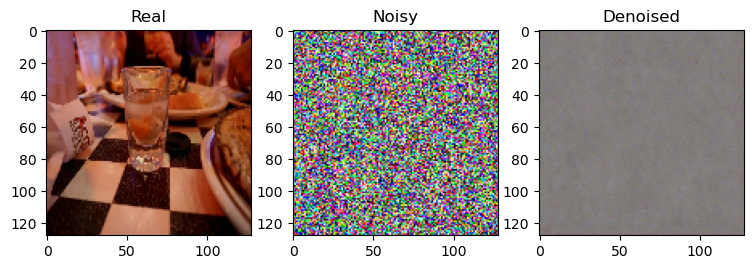

In [39]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 3, figsize=(9, 3))
axs[0].imshow((image[0] + 1) / 2); axs[0].set_title("Real")
axs[1].imshow((noisy[0] + 1) / 2); axs[1].set_title("Noisy")
axs[2].imshow(((noisy - pred)[0] + 1) / 2); axs[2].set_title("Denoised")
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5633061..2.68602].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5510643..2.9175603].


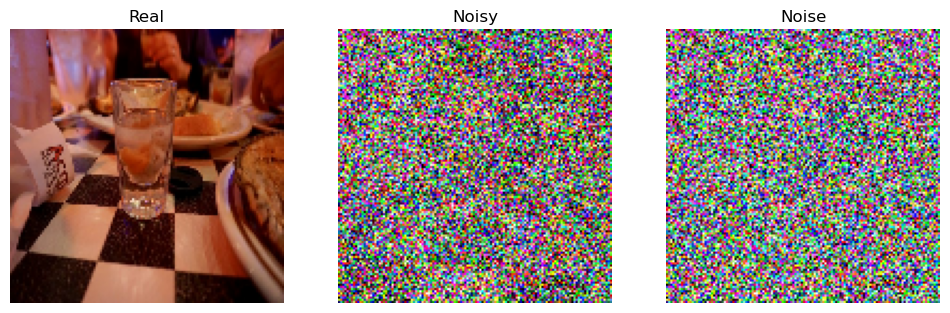

In [41]:
x0 = preprocess_image("data/photos/vkr8T0scuJmGVvN2HJelEA.jpg")[None]
t = tf.constant([500])
noise = tf.random.normal(tf.shape(x0))
noisy = scheduler.add_noise(x0, t, noise)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Real")
plt.imshow(((x0[0] + 1) / 2).numpy())
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Noisy")
plt.imshow(((noisy[0] + 1) / 2).numpy())
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Noise")
plt.imshow(((noise[0] + 1) / 2).numpy())
plt.axis("off")
plt.show()


# First Epoch sample images

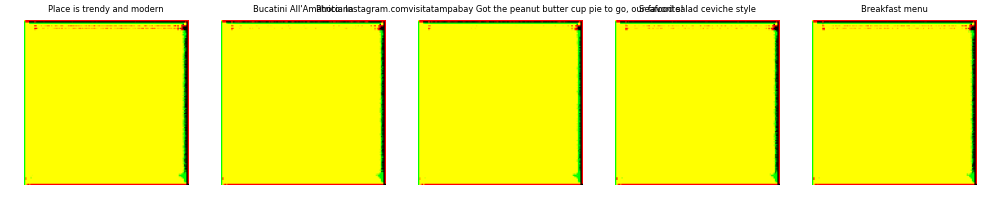

# Mid Epoch sample images

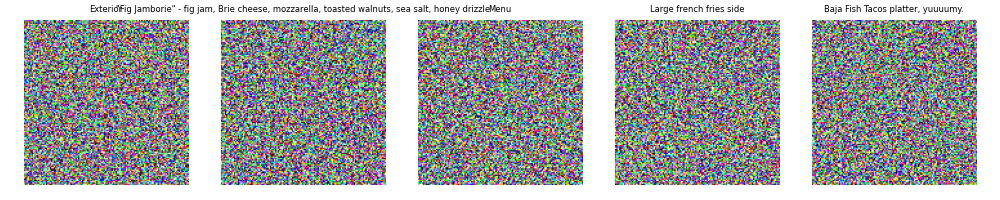

# Last Epoch sample images

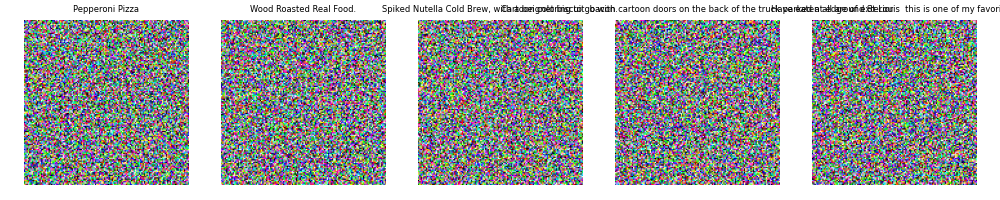